Found 35 .pt files in AXT1PRE_normalized
Loaded 16 slices
torch.Size([2, 384, 384])
torch.Size([2, 384, 384])
torch.Size([2, 384, 384])
torch.Size([2, 384, 384])
torch.Size([2, 384, 384])
torch.Size([2, 384, 384])
torch.Size([2, 384, 384])
torch.Size([2, 384, 384])
torch.Size([2, 384, 384])
torch.Size([2, 384, 384])
torch.Size([2, 384, 384])
torch.Size([2, 384, 384])
torch.Size([2, 384, 384])
torch.Size([2, 384, 384])
torch.Size([2, 384, 384])
torch.Size([2, 384, 384])


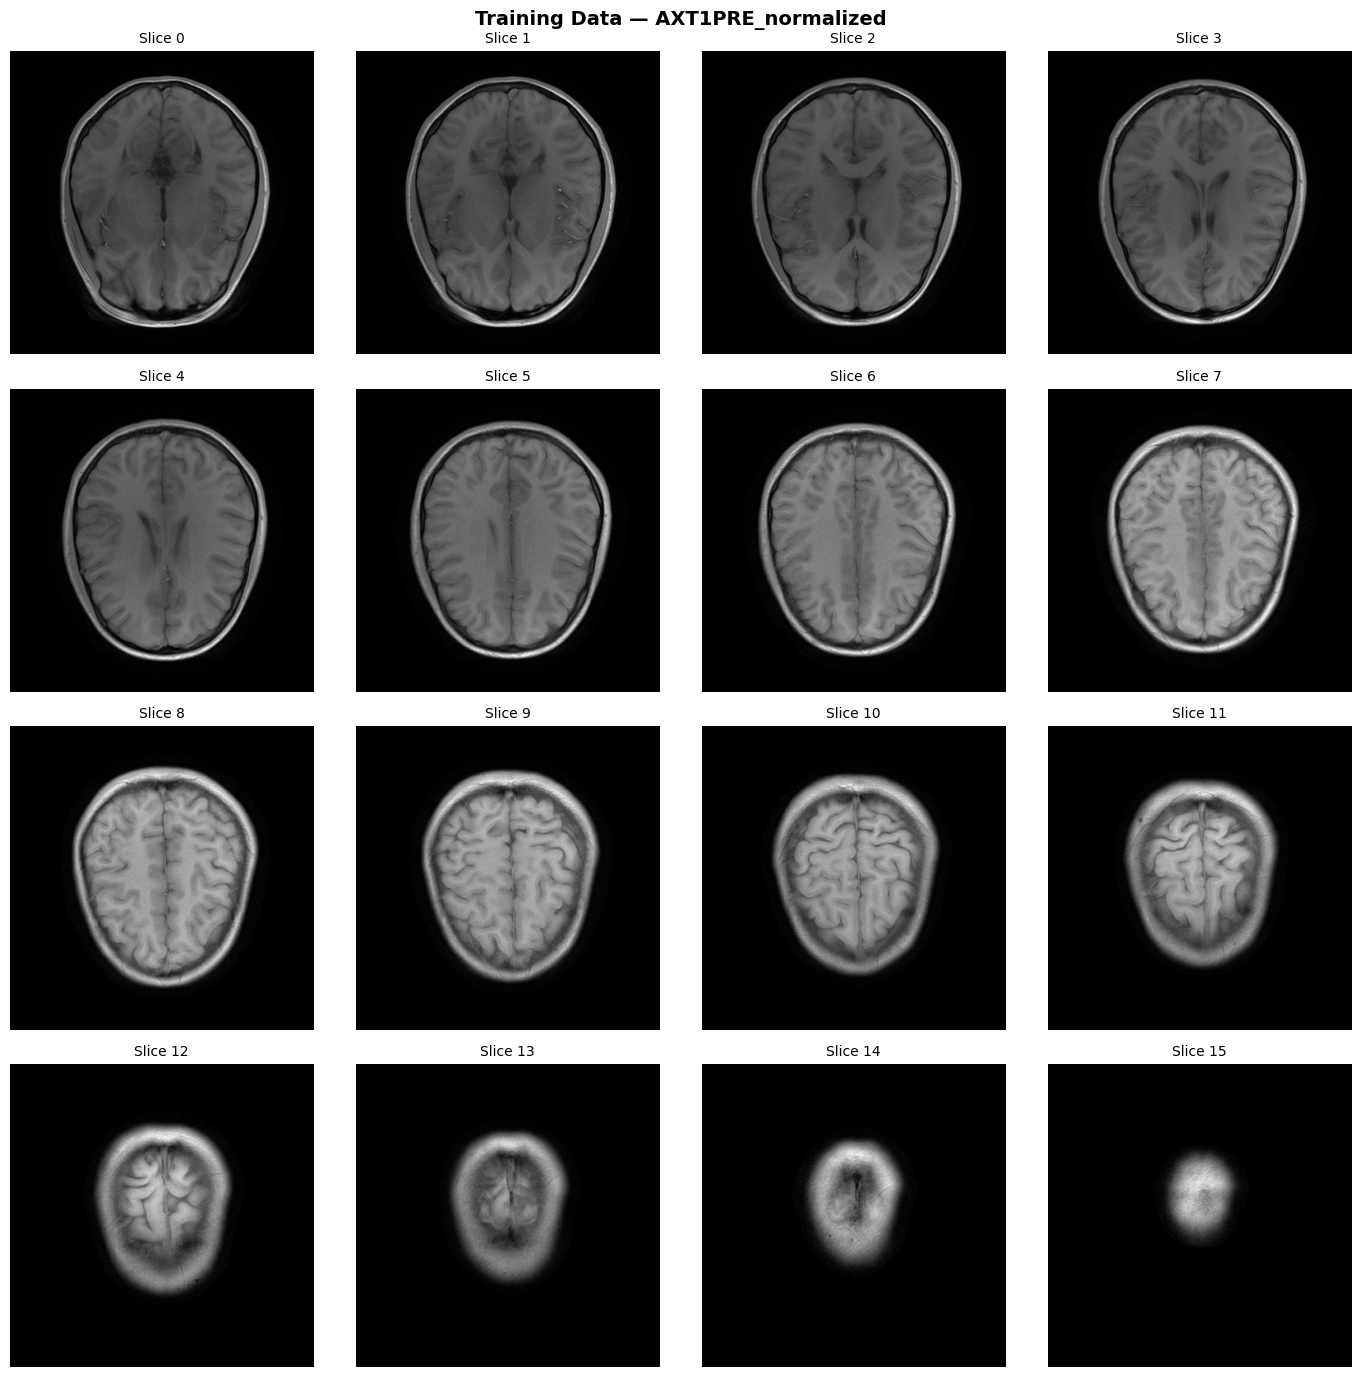

In [3]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ============================================
# PLOT TRAINING IMAGES FOR A CONTRAST
# ============================================
data_root = "/home/../mnt/data3/ruy45/dataset/processed_data"  # parent of contrast folders
contrast = "AXT1PRE_normalized"  # change as needed
num_images = 16  # how many slices to show
ncols = 4

# Collect slices
contrast_dir = Path(data_root) / contrast
pt_files = sorted(contrast_dir.rglob("*.pt"))
print(f"Found {len(pt_files)} .pt files in {contrast_dir.name}")

slices = []
for f in pt_files:
    obj = torch.load(f, map_location="cpu")
    if "slices" not in obj:
        continue
    for s in range(obj["slices"].shape[0]):
        slices.append(obj["slices"][s])  # (2, H, W)
        if len(slices) >= num_images:
            break
    if len(slices) >= num_images:
        break

print(f"Loaded {len(slices)} slices")

# Plot
nrows = (len(slices) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3.5 * nrows))
axes = np.array(axes).reshape(-1)

for i, ax in enumerate(axes):
    if i < len(slices):
        img = slices[i]
        print(img.shape)
        # Magnitude from 2-channel complex
        if img.shape[0] == 2:
            mag = torch.sqrt(img[0] ** 2 + img[1] ** 2)
        else:
            mag = img[0]
        ax.imshow(mag.numpy(), cmap="gray")
        ax.set_title(f"Slice {i}", fontsize=10)
    ax.axis("off")

fig.suptitle(f"Training Data — {contrast}", fontsize=14, fontweight="bold")
plt.tight_layout()
# plt.savefig(f"training_samples_{contrast}.png", dpi=150, bbox_inches="tight")
plt.show()


In [2]:
img.shape

torch.Size([2, 384, 384])

In [ ]:
import torch
from pathlib import Path
from collections import defaultdict

# ============================================
# COUNT .pt FILES AND SLICES BY SUBFOLDER
# ============================================
data_root = Path("/home/../mnt/data3/ruy45/dataset/processed_data").resolve()

if not data_root.exists():
    raise FileNotFoundError(f"data_root not found: {data_root}")

stats = defaultdict(lambda: {
    "pt_count": 0,
    "slice_count": 0,
    "missing_slices_key": 0,
    "load_error": 0,
})

pt_files = sorted(data_root.rglob("*.pt"))
for f in pt_files:
    top_subfolder = f.relative_to(data_root).parts[0]
    stats[top_subfolder]["pt_count"] += 1

    try:
        obj = torch.load(f, map_location="cpu")
        if isinstance(obj, dict) and "slices" in obj and hasattr(obj["slices"], "shape"):
            stats[top_subfolder]["slice_count"] += int(obj["slices"].shape[0])
        else:
            stats[top_subfolder]["missing_slices_key"] += 1
    except Exception:
        stats[top_subfolder]["load_error"] += 1

# Totals
total_pt = sum(v["pt_count"] for v in stats.values())
total_slices = sum(v["slice_count"] for v in stats.values())

print(f"Data root: {data_root}")
print(f"Total .pt files: {total_pt}")
print(f"Total slices: {total_slices}")
print()
print("subfolder	pt_count	slice_count	missing_slices_key	load_error")
for subfolder in sorted(stats):
    s = stats[subfolder]
    print(
        f"{subfolder}	{s['pt_count']}	{s['slice_count']}	"
        f"{s['missing_slices_key']}	{s['load_error']}"
    )

